<a href="https://colab.research.google.com/github/NickKar30/GM-HSE-AI-masters-course/blob/main/Hometasks/Base/GenDL_HT1_base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание - 1 (базовая группа)

В этом домашнем задании вы потренируетесь решать задачу speech-to-text.

Вы не будете тренировать сложную архитектуру с нуля, а попробуете решить эту задачу, пройдя по пайплайну, в котором задача разбита на несколько простых шагов.

- В этом задании мы призываем вас по-максимуму использовать документацию моделей и получить опыт написания кода без заготовок

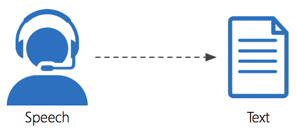

In [1]:
!pip install evaluate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00


## Шаг 1 (1 балл)

* Возьмите датасет https://disk.yandex.ru/d/v2Hipv7XG4fEDQ, содержащий русскоязычные аудиозаписи

* Примените модель [whisper-small](https://huggingface.co/openai/whisper-small) из HF для определения сказанного в аудио.

* Выведите результат работы модели для 10 случайных аудио из датасета

Не стесняйтесь пользоваться документацией и источниками знаний из интернета!

In [2]:
from transformers import WhisperForConditionalGeneration, WhisperProcessor
import torch
import torchaudio
import os
import random
from pathlib import Path
import pandas as pd
import requests

In [ ]:
audio_dir = "audio"
Path(audio_dir).mkdir(exist_ok=True)

with open('urls_normalized.tsv', 'r') as f:
    urls = [line.strip() for line in f if line.strip()]

def download_audio(url, filename):
    try:
        response = requests.get(url, timeout=10)
        with open(filename, 'wb') as f:
            f.write(response.content)
        return True
    except Exception as e:
        print(f"Ошибка при скачивании {url}: {e}")
        return False

downloaded_files = []

for i, audio_url in enumerate(urls):
    filename = os.path.join(audio_dir, f"audio_{i}.wav")
    if download_audio(audio_url, filename):
        downloaded_files.append(filename)
        print(f"Загружен: {filename}")
    else:
        print(f"Не удалось загрузить {filename}")

print(f"\nСкачано {len(downloaded_files)} файлов")

Загружен: audio/audio_0.wav
Загружен: audio/audio_1.wav
Загружен: audio/audio_2.wav
Загружен: audio/audio_3.wav
Загружен: audio/audio_4.wav
Загружен: audio/audio_5.wav
Загружен: audio/audio_6.wav
Загружен: audio/audio_7.wav
Загружен: audio/audio_8.wav
Загружен: audio/audio_9.wav
Загружен: audio/audio_10.wav
Загружен: audio/audio_11.wav
Загружен: audio/audio_12.wav
Загружен: audio/audio_13.wav
Загружен: audio/audio_14.wav
Загружен: audio/audio_15.wav
Загружен: audio/audio_16.wav
Загружен: audio/audio_17.wav
Загружен: audio/audio_18.wav
Загружен: audio/audio_19.wav
Загружен: audio/audio_20.wav
Загружен: audio/audio_21.wav
Загружен: audio/audio_22.wav
Загружен: audio/audio_23.wav
Загружен: audio/audio_24.wav
Загружен: audio/audio_25.wav
Загружен: audio/audio_26.wav
Загружен: audio/audio_27.wav
Загружен: audio/audio_28.wav
Загружен: audio/audio_29.wav
Загружен: audio/audio_30.wav
Загружен: audio/audio_31.wav
Загружен: audio/audio_32.wav
Загружен: audio/audio_33.wav
Загружен: audio/audio_34

In [ ]:
random.seed(28)
sample_files = random.sample(downloaded_files, k=min(10, len(downloaded_files)))

In [ ]:
processor = WhisperProcessor.from_pretrained("openai/whisper-small")
model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-small")

preprocessor_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

generation_config.json: 0.00B [00:00, ?B/s]

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
results = []
for path in sample_files:
    wav, sr = torchaudio.load(path)
    if sr != 16000:
        wav = torchaudio.functional.resample(wav, orig_freq=sr, new_freq=16000)
        sr = 16000
    if wav.shape[0] > 1:
        wav = torch.mean(wav, dim=0, keepdim=True)
    input_features = processor(wav.squeeze(), sampling_rate=sr, return_tensors="pt").input_features
    predicted_ids = model.generate(input_features, max_new_tokens=128, language="ru", task="transcribe")
    transcription = processor.batch_decode(predicted_ids, skip_special_tokens=True)[0]
    results.append({"audio": os.path.basename(path), "transcription": transcription})
    print(f"\n{os.path.basename(path)}:\n{transcription}")

pd.DataFrame(results).to_csv("sample_10.csv", index=False)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.



audio_14.wav:
 Андрей Сахаров

audio_95.wav:
 Помни!

audio_16.wav:
 Зеленая книга.

audio_69.wav:
 Индиана Джонс и последний крестовый поход.

audio_76.wav:
 Бред пит

audio_91.wav:
 Жан-поль-сартер

audio_22.wav:
 Шон Бин

audio_28.wav:
 Крестный отец 2

audio_81.wav:
 Александр Владимирович Попов

audio_59.wav:
 Нокдаун


In [ ]:
df = pd.read_csv("sample_10.csv")
df

,audio,transcription
0,audio_14.wav,Андрей Сахаров
1,audio_95.wav,Помни!
2,audio_16.wav,Зеленая книга.
3,audio_69.wav,Индиана Джонс и последний крестовый поход.
4,audio_76.wav,Бред пит
5,audio_91.wav,Жан-поль-сартер
6,audio_22.wav,Шон Бин
7,audio_28.wav,Крестный отец 2
8,audio_81.wav,Александр Владимирович Попов
9,audio_59.wav,Нокдаун


## Шаг 2 (1 балл)

Текст распознается с ошибками.
Попробуйте исправить ошибки с помощью готовой (предобученной) модели spell correction.

Выведите на экран 10 текстов с предыдущего шага и их исправления с помощью модели https://huggingface.co/UrukHan/t5-russian-spell.

In [4]:
from transformers import AutoModelForSeq2SeqLM, T5TokenizerFast

In [ ]:
tokenizer = T5TokenizerFast.from_pretrained('UrukHan/t5-russian-spell')
model = AutoModelForSeq2SeqLM.from_pretrained('UrukHan/t5-russian-spell')

def spell_correction(text):
    task_prefix = "Spell correct: "
    input_text = task_prefix + text
    inputs = tokenizer(
        input_text,
        return_tensors="pt",
        max_length=256,
        padding='max_length',
        truncation=True
    )
    outputs = model.generate(
        **inputs,
        max_length=256,
        num_beams=5,
        early_stopping=True
    )
    corrected_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return corrected_text

In [ ]:
df["correct"] = df["transcription"].apply(lambda x: spell_correction(x))
df

,audio,transcription,correct
0,audio_14.wav,Андрей Сахаров,Андрей Сахаров
1,audio_95.wav,Помни!,Помни!
2,audio_16.wav,Зеленая книга.,Зеленая книга.
3,audio_69.wav,Индиана Джонс и последний крестовый поход.,Индиана Джонс и последний крестовый поход.
4,audio_76.wav,Бред пит,Бред Питт
5,audio_91.wav,Жан-поль-сартер,Жан-Поль-Сартер
6,audio_22.wav,Шон Бин,Шон Бин
7,audio_28.wav,Крестный отец 2,Крестный отец 2
8,audio_81.wav,Александр Владимирович Попов,Александр Владимирович Попов
9,audio_59.wav,Нокдаун,Нокдаун


## Шаг 3 (2 балла)

Соберите данные для дообучения модели выше. Для дообучения мы предлагаем вам использовать бесплатный api Groq: https://console.groq.com/docs/quickstart

Разберитесь с тем как пользоваться api (мы немного поможем вам с этим кодом ниже) и с его помощью соберите датасет (можно в несколько запросов).

- **0.5 балла** ставится за сбор датасета размером >1000 строк и сохранение в локальный файл/файлы

- **еще 0.5 балла** ставится за [создание huggingface dataset](https://huggingface.co/docs/datasets/create_dataset) (через использование библиотек datasets и huggingface) и [сохранение собранного датасета напрямую в HuggingFace](https://huggingface.co/docs/datasets/upload_dataset)

- **еще 1 балл** ставится за сбор датасета размером >1000 строк, на котором путем дообучения получится увеличить качество исправления опечаток в поставленной задаче (см. шаг 6) по сравнению с качеством прогноза той же, но предобученной модели

P.S. Если у Вас нет VPN, то можете воспользоваться другой LLM на Ваш выбор (можно, например, этим https://ollama.com/).

In [ ]:
# зайдите на страницу и создайте API KEY: https://console.groq.com/keys - возможно, понадобится включить VPN

import os

# os.environ["GROQ_API_KEY"] = "" 

In [ ]:
!pip install groq

In [ ]:
import json, time
from groq import Groq
from datasets import Dataset
from tqdm import tqdm

In [ ]:
prompt_temp = """Сгенерируй список на русском языке из {N} фильмов, популярных примерно в {YEAR} году.
Названия фильмов должно быть без указания года или страны, только название фильма, без уточнений.
Также для каждого названия сгенерируй вариант с ошибкой ASR: замена букв (о→a), пропущенные пробелы, слитые слова, транслитерация, фрагменты на английском, пропущенные буквы, неправильный регистр, расхождения в пунктуации.
Формат вывода: [{'correct': 'название фильма', 'noisy': 'название фильма с ошибкой'}]
Выведи только JSON без комментариев, текста или форматирования кода.
"""

In [ ]:
client = Groq(api_key=os.environ.get("GROQ_API_KEY"))

In [ ]:
def gen_batch(n=50, year=2000, retries=3):
    prompt = prompt_temp.replace("{N}", str(n)).replace("{YEAR}", str(year))
    messages = [{"role": "user", "content": prompt}]
    for attempt in range(retries):
        try:
            resp = client.chat.completions.create(
                messages=messages,
                model="llama-3.1-8b-instant",
                max_tokens=2000,
            )
            content = resp.choices[0].message.content.strip()
            data = json.loads(content)
            validated_data = []
            for item in data:
                if isinstance(item, dict) and "correct" in item and "noisy" in item and item["correct"] and item["noisy"] and len(str(item["correct"]).strip()) > 0 and len(str(item["noisy"]).strip()) > 0:
                    validated_item = {
                        "correct": item["correct"],
                        "noisy": item["noisy"]
                    }
                    validated_data.append(validated_item)
            if validated_data:
                return validated_data

            print(f"Формат неверен ({year}), попытка {attempt+1}")
            time.sleep(2)
        except Exception as e:
            print(f"Ошибка на попытке {attempt+1} ({year}): {e}")
            time.sleep(3)
    return []

In [ ]:
all_pairs = []
for i in tqdm(range(20)):
    year = 1995 + i
    batch = gen_batch(n=50, year=year)
    if batch:
        all_pairs.extend(batch)
        print(f"\n{year}: {len(batch)} фильмов")

  0%|          | 0/20 [00:00<?, ?it/s]

Формат неверен (1995), попытка 1


  5%|▌         | 1/20 [00:07<02:23,  7.54s/it]


1995: 61 фильмов


 10%|█         | 2/20 [00:10<01:23,  4.65s/it]

...


2012: 55 фильмов
Ошибка на попытке 1 (2013): Expecting ',' delimiter: line 65 column 41 (char 4054)


 95%|█████████▌| 19/20 [02:52<00:11, 11.70s/it]


2013: 56 фильмов


100%|██████████| 20/20 [02:57<00:00,  8.88s/it]


2014: 47 фильмов


In [ ]:
unique = { (x["noisy"], x["correct"]) : x for x in all_pairs }
pairs = list(unique.values())
df_gen = pd.DataFrame(pairs)
df_gen.to_csv("MY_DATASET.csv", index=False)
df_gen.shape

(1133, 2)

In [ ]:
df_gen.head()

,correct,noisy
0,Первый мюнхгаузен,Первий Мюнхгаузен
1,Правила игры,правила игры
2,Семейка Аддамс,семейка аддамc
3,Клуб любителей книг,клуб любителей книг
4,Матрица,матриса


In [ ]:
from huggingface_hub import HfApi, HfFolder

In [ ]:
# os.environ["HF_TOKEN"] = " "

In [ ]:
HF_TOKEN = os.environ.get("HF_TOKEN")
REPO_NAME = "MY_DATASET_HUGF"
USERNAME = "KlimaIlya"
REPO_ID = f"{USERNAME}/{REPO_NAME}"

In [ ]:
df_hugf = Dataset.from_pandas(df_gen)
df_hugf.save_to_disk("MY_DATASET_HUGF")

Saving the dataset (0/1 shards):   0%|          | 0/1133 [00:00<?, ? examples/s]

In [ ]:
api = HfApi()
HfFolder.save_token(HF_TOKEN)
api.create_repo(repo_id=REPO_ID, private=False, repo_type="dataset", exist_ok=True)
df_hugf.push_to_hub(REPO_ID, token=HF_TOKEN)
print(f"Датасет загружен: https://huggingface.co/datasets/{REPO_ID}")

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/2 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              : 100%|##########| 43.4kB / 43.4kB            

                              : 100%|##########| 43.4kB / 43.4kB            

Датасет загружен: https://huggingface.co/datasets/KlimaIlya/MY_DATASET_HUGF


датасет https://huggingface.co/datasets/KlimaIlya/MY_DATASET_HUGF

## Шаг 4 (2 балла)

Дообучите модель выше или любую другую модель, которая вам нравится, на собранных данных и протестируйте ее на нескольких ошибочно распознанных whisper-small моделью аудио. Дообучение мы разбирали на семинаре - можете посмотреть, как мы это делали там.

Для оценки качества результата выведите на экран 10 текстов с предыдущего шага и их исправления с помощью модели.

- Вы можете воспользовать структурой, предложенной в ячейке ниже, а можете написать код по-своему.

In [ ]:
!pip install --upgrade transformers datasets

In [ ]:
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq, Seq2SeqTrainer, Seq2SeqTrainingArguments

dataset = load_dataset("csv", data_files="MY_DATASET.csv")
dataset = dataset["train"].train_test_split(test_size=0.1, seed=42)

tokenizer = AutoTokenizer.from_pretrained("UrukHan/t5-russian-spell")
model = AutoModelForSeq2SeqLM.from_pretrained("UrukHan/t5-russian-spell")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Generating train split: 0 examples [00:00, ? examples/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/1.00M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

T5ForConditionalGeneration(
  (shared): Embedding(32128, 768)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 768)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=768, out_features=768, bias=False)
              (k): Linear(in_features=768, out_features=768, bias=False)
              (v): Linear(in_features=768, out_features=768, bias=False)
              (o): Linear(in_features=768, out_features=768, bias=False)
              (relative_attention_bias): Embedding(32, 12)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseActDense(
              (wi): Linear(in_features=768, out_features=3072, bias=False)
              (wo): Linear(in_features=3072, out_features=768, bias=False)
              (dropout): Dro

In [8]:
import os
os.environ["WANDB_DISABLED"] = "true"

In [ ]:
def preprocess(batch):
    inputs = tokenizer(batch["noisy"], truncation=True, padding="max_length", max_length=64)
    labels = tokenizer(batch["correct"], truncation=True, padding="max_length", max_length=64)
    inputs["labels"] = labels["input_ids"]
    return inputs

tokenized = dataset.map(preprocess, batched=True, remove_columns=dataset["train"].column_names)

data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

training_args = Seq2SeqTrainingArguments(
    output_dir="./t5_spell_finetuned",
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=50,
    save_total_limit=1,
    predict_with_generate=True,
    save_strategy="epoch",
    eval_strategy="epoch",
    fp16=torch.cuda.is_available(),
    report_to=None,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["test"],
    tokenizer=tokenizer,
    data_collator=data_collator,
)

trainer.train()

model.save_pretrained("t5_spell_finetuned")
tokenizer.save_pretrained("t5_spell_finetuned")

Map:   0%|          | 0/1019 [00:00<?, ? examples/s]

Map:   0%|          | 0/114 [00:00<?, ? examples/s]

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Epoch,Training Loss,Validation Loss
1,2.110100,0.169231
2,0.176200,0.133088
3,0.153400,0.125910


('t5_spell_finetuned/tokenizer_config.json',
 't5_spell_finetuned/special_tokens_map.json',
 't5_spell_finetuned/spiece.model',
 't5_spell_finetuned/added_tokens.json',
 't5_spell_finetuned/tokenizer.json')

Примените дообученную модель. Как раз здесь для оценки качества результата выведите на экран 10 текстов с предыдущего шага и их исправления с помощью модели.

In [ ]:
model_path = "./t5_spell_finetuned"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSeq2SeqLM.from_pretrained(model_path)

def spell_correction(text):
    task_prefix = "Spell correct: "
    input_text = task_prefix + text
    inputs = tokenizer(
        input_text,
        return_tensors="pt",
        max_length=256,
        padding='max_length',
        truncation=True
    )
    outputs = model.generate(
        **inputs,
        max_length=256,
        num_beams=5,
        early_stopping=True
    )
    corrected_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return corrected_text

df = pd.read_csv("sample_10.csv")
df["correct"] = df["transcription"].apply(lambda x: spell_correction(x))
df

,audio,transcription,correct
0,audio_14.wav,Андрей Сахаров,Андрей Сахаров
1,audio_95.wav,Помни!,Помни!
2,audio_16.wav,Зеленая книга.,Зеленая книга
3,audio_69.wav,Индиана Джонс и последний крестовый поход.,Индиана Джонс и последний крестовый поход
4,audio_76.wav,Бред пит,Бред Пит
5,audio_91.wav,Жан-поль-сартер,Жан-Поль-Сарт
6,audio_22.wav,Шон Бин,Шон Бин
7,audio_28.wav,Крестный отец 2,Крестный отец 2
8,audio_81.wav,Александр Владимирович Попов,Александр Владимирович Попов
9,audio_59.wav,Нокдаун,Нокдаун


In [ ]:
df_gpt = pd.read_csv("MY_DATASET.csv")
random_indices = random.sample(range(len(df_gpt)), 10)
df_gpt_test = df_gpt.iloc[random_indices].copy()
df_gpt_test ["model_corrected"] = df_gpt_test ["noisy"].apply(lambda x: spell_correction(x))
df_gpt_test

,correct,noisy,model_corrected
833,Альтич,альтчик,Альтчик
491,Гражданин милиции,grazhdanin milici,Гражданин смерти
142,Тайна Квентина Тарантино за неделю,"taina Kventina Taranino za needeli, tain Kvent...",Капитан Квентина: Таранино за рулем
194,Парк южной пальмиры и,Park iuznoj Pal myri i,Парк Волшебный камень
860,Сердце-Змея,сердце-змея,Сердце-змея
644,Мститель-9,Мститель-9,Мститель-9
265,Следы преступления,слиды прeстypления,Следы преступления
361,Баба Яга,BABI JA,BABI JA
1037,Ведьма из Блэр,vedmja iz blerr,Ведомая из Берлина
1064,Эрнест и Селестин,"ernest i selestina, ernest i celestina, ернест...",Бернест и Селезтина


## Шаг 5 (1 балл)

Время считать метрики и возвращаться к дообучению модели по необходимости. В этом шаге мы оцениваем только выполнение задания, а не значения метрик.

a) [Здесь](https://disk.yandex.ru/d/SPJU3lCt_cMDcw) лежат правильные ответы почти на все аудио - считайте метрики только для аудио, для которых мы дали вам ответы. Посчитайте [WER](https://docs.pytorch.org/torcheval/main/generated/torcheval.metrics.WordErrorRate.html) для модели whisper-small.

б) Посчитайте WER для whisper-small + исправление опечаток предобученной моделью (модель выберите самостоятельно!)

в) Посчитайте WER для whisper-small + дообученная Вами модель (данные для дообучения и модель выберите самостоятельно!)

In [9]:
!pip install torcheval

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 7.8 MB/s eta 0:00:00


In [10]:
from transformers import WhisperProcessor, WhisperForConditionalGeneration
from torcheval.metrics.functional import word_error_rate as wer
import re

In [11]:
def transcribe_whisper(path):
    wav, sr = torchaudio.load(path)
    if sr != 16000:
        wav = torchaudio.functional.resample(wav, orig_freq=sr, new_freq=16000)
    if wav.shape[0] > 1:
        wav = torch.mean(wav, dim=0, keepdim=True)
    input_features = processor(wav.squeeze(), sampling_rate=16000, return_tensors="pt").input_features.to(device)
    predicted_ids = whisper_model.generate(input_features, max_new_tokens=128, language="ru", task="transcribe")
    transcription = processor.batch_decode(predicted_ids, skip_special_tokens=True)[0].lower()
    return transcription

def spell_correction(text, tokenizer, model):
    task_prefix = "Spell correct: "
    input_text = task_prefix + text
    inputs = tokenizer(input_text, return_tensors="pt", max_length=256, padding='max_length', truncation=True).to(device)
    outputs = model.generate(**inputs, max_length=256, num_beams=5, early_stopping=True)
    corrected_text = tokenizer.decode(outputs[0], skip_special_tokens=True).lower()
    return corrected_text

def normalize_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
processor = WhisperProcessor.from_pretrained("openai/whisper-small")
whisper_model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-small").to(device)

tokenizer_pre = AutoTokenizer.from_pretrained('UrukHan/t5-russian-spell')
model_pre = AutoModelForSeq2SeqLM.from_pretrained('UrukHan/t5-russian-spell').to(device)

tokenizer_finetun = AutoTokenizer.from_pretrained("./t5_spell_finetuned")
model_finetun = AutoModelForSeq2SeqLM.from_pretrained("./t5_spell_finetuned").to(device)

In [ ]:
AUDIO_DIR = "audio"
Path(AUDIO_DIR).mkdir(exist_ok=True)
results = []
with open("result_array.json", "r", encoding="utf-8") as f:
    data = json.load(f)

for i, item in enumerate(data):
    url = item["url"]
    text = item["text"]
    filename = os.path.join(AUDIO_DIR, f"audio_{i}.wav")
    if not download_audio(url, filename):
        continue
    whisper_text = transcribe_whisper(filename)
    pretrained_text = spell_correction(whisper_text, tokenizer, model_pre)
    finetuned_text = spell_correction(whisper_text, tokenizer, model_finetun)
    results.append({
        "text": text,
        "whisper": whisper_text,
        "pretrained": pretrained_text,
        "finetuned": finetuned_text
    })

df_results = pd.DataFrame(results)

In [ ]:
df_results

,text,whisper,pretrained,finetuned
0,жизнь других,жизнь других,жизнь других,жизнь других
1,элтон джон,аутам джон,аутам джонс,аутам джонс
2,побег из шоушенка,побег из шаушенко,побег из шаушенко,побег из шоушенко
3,мухаммед али,мохаммед али,мохаммед али,мохаммед али
4,дневник памяти,дневник памяти,дневник памяти,дневник памяти
...,...,...,...,...
91,помни,помни,помни,помни
92,элизабет бэнкс,elizabeth banks,elizabeth banks,lizabeth banks
93,новый кинотеатр парадизо,новый кинотеатр пародизо,новый кинотеатр пародии,новый кинотеатр пародии
94,крепкий орешек,крепкий орешек,крепкий орешек,крепкий орех


In [ ]:
df_results["whisper"] = df_results["whisper"].apply(normalize_text)
df_results["pretrained"] = df_results["pretrained"].apply(normalize_text)
df_results["finetuned"] = df_results["finetuned"].apply(normalize_text)

wer_whisper = wer([r["whisper"] for r in results], [r["text"] for r in results])
wer_pretrained = wer([r["pretrained"] for r in results], [r["text"] for r in results])
wer_finetuned = wer([r["finetuned"] for r in results], [r["text"] for r in results])
print(f"WER Whisper: {wer_whisper}")
print(f"WER Whisper + pretrained spell-correction: {wer_pretrained}")
print(f"WER Whisper + finetuned spell-correction: {wer_finetuned}")

WER Whisper: 0.4956521739130435
WER Whisper + pretrained spell-correction: 0.808695652173913
WER Whisper + finetuned spell-correction: 0.41739130434782606


## Шаг 6 (3 балла)

В этом шаге предлагаем вам провести максимум рисерча и экспериментов для наиболее качественного решения задачи (в бесплатном google colab, без привлечения дополнительных мощностей)

* Поищите предобученные модели, применение которых для задачи speech-to-text дает меньше опечаток (меньше WER)

* Протестируйте несколько spell-correction моделей и сделайте выводы какая из них лучше (с точки зрения WER)

* Возьмите лучшую из найденных моделей и попытайтесь улучшить ее через шаг 4, как делали ранее. Попробуйте немного изменить обучение в шаге 4, чтобы добиться еще более хороших результатов (изменить данные/гиперпараметры и т.п.) и проведите соответствующий эксперимент. Объясните почему ваша модификация шага 4 теоретически может улучшить результаты и сделайте выводы о том, получилось ли улучшить качество (если нет, то предположите почему).

In [14]:
import gc

In [15]:
def transcribe_whisper(path, processor, whisper_model):
    wav, sr = torchaudio.load(path)
    if sr != 16000:
        wav = torchaudio.functional.resample(wav, orig_freq=sr, new_freq=16000)
    if wav.shape[0] > 1:
        wav = torch.mean(wav, dim=0, keepdim=True)
    input_features = processor(wav.squeeze(), sampling_rate=16000, return_tensors="pt").input_features.to(device)
    predicted_ids = whisper_model.generate(input_features, max_new_tokens=128, language="ru", task="transcribe")
    transcription = processor.batch_decode(predicted_ids, skip_special_tokens=True)[0]
    return transcription

In [ ]:
AUDIO_MODELS = [
    ("whisper-medium", "openai/whisper-medium"),
    ("whisper-large-v3", "openai/whisper-large-v3")
]

SPELL_MODELS = [
    ("t5", "UrukHan/t5-russian-spell"),
    ("sage-fredt5-95m", "ai-forever/sage-fredt5-distilled-95m")
]

In [16]:
with open("result_array.json", "r", encoding="utf-8") as f:
    gt_data = json.load(f)
gt_dict = {os.path.basename(item["url"]): item["text"].strip().lower() for item in gt_data}

In [ ]:
results = []

for name, id in AUDIO_MODELS:
    processor = WhisperProcessor.from_pretrained(id)
    whisper_model = WhisperForConditionalGeneration.from_pretrained(id).to(device)
    for spell_name, spell_id in SPELL_MODELS:
        tokenizer = AutoTokenizer.from_pretrained(spell_id)
        spell_model = AutoModelForSeq2SeqLM.from_pretrained(spell_id).to(device)
        texts, whisper_texts, spell_texts = [], [], []
        for i, item in enumerate(gt_data):
            url = item["url"]
            text = item["text"]
            filename = os.path.join(AUDIO_DIR, f"audio_{i}.wav")
            if not os.path.exists(filename):
                continue
            whisper_pred = normalize_text(transcribe_whisper(filename, processor, whisper_model))
            spell_pred = normalize_text(spell_correction(whisper_pred, tokenizer, spell_model))
            texts.append(text)
            whisper_texts.append(whisper_pred)
            spell_texts.append(spell_pred)

        wer_whisper = wer(texts, whisper_texts)
        wer_spell = wer(texts, spell_texts)
        print(f"({name}): wer = {wer_whisper}")
        print(f"{name} + {spell_name}: wer = {wer_spell}\n")

        results.append({
            "model_audio": name,
            "model_spell": spell_name,
            "WER_Whisper": float(wer_whisper),
            "WER_Spell": float(wer_spell)
        })
        del tokenizer, spell_model
        gc.collect()
        torch.cuda.empty_cache()

    del processor, whisper_model
    gc.collect()
    torch.cuda.empty_cache()

df_results = pd.DataFrame(results)
df_results

(whisper-medium): wer = 0.3217391304347826
whisper-medium + t5: wer = 0.31601731601731603

(whisper-medium): wer = 0.3217391304347826
whisper-medium + sage-fredt5-95m: wer = 0.624113475177305

(whisper-large-v3): wer = 0.15350877192982457
whisper-large-v3 + t5: wer = 0.18421052631578946

(whisper-large-v3): wer = 0.15350877192982457
whisper-large-v3 + sage-fredt5-95m: wer = 0.5452380952380952



,model_audio,model_spell,WER_Whisper,WER_Spell
0,whisper-medium,t5,0.321739,0.316017
1,whisper-medium,sage-fredt5-95m,0.321739,0.624113
2,whisper-large-v3,t5,0.153509,0.184211
3,whisper-large-v3,sage-fredt5-95m,0.153509,0.545238


Лучшей моделью стала whisper-large-v3 + t5 ( в абсолютном чистая whisper-large-v3)

In [17]:
dataset = load_dataset("csv", data_files="MY_DATASET.csv")["train"].train_test_split(test_size=0.1, seed=42)
tokenizer = AutoTokenizer.from_pretrained("UrukHan/t5-russian-spell")
model = AutoModelForSeq2SeqLM.from_pretrained("UrukHan/t5-russian-spell").to(device)
def preprocess(batch):
    inputs = tokenizer(batch["noisy"], truncation=True, padding="max_length", max_length=128)
    labels = tokenizer(batch["correct"], truncation=True, padding="max_length", max_length=128)
    inputs["labels"] = labels["input_ids"]
    return inputs

tokenized_train = dataset["train"].map(preprocess, batched=True, remove_columns=["noisy", "correct"])
tokenized_test  = dataset["test"].map(preprocess, batched=True, remove_columns=["noisy", "correct"])
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

training_args = Seq2SeqTrainingArguments(
    output_dir="./t5_spell_finetuned_v2",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=50,
    save_total_limit=2,
    predict_with_generate=True,
    save_strategy="epoch",
    eval_strategy="epoch",
    fp16=torch.cuda.is_available(),
    report_to=None
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    tokenizer=tokenizer,
    data_collator=data_collator
)

trainer.train()
model.save_pretrained("./t5_spell_finetuned_v2")
tokenizer.save_pretrained("./t5_spell_finetuned_v2")

del trainer, tokenized_train, tokenized_test
gc.collect()
torch.cuda.empty_cache()

Generating train split: 0 examples [00:00, ? examples/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/1.00M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

Map:   0%|          | 0/1019 [00:00<?, ? examples/s]

Map:   0%|          | 0/114 [00:00<?, ? examples/s]

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Epoch,Training Loss,Validation Loss
1,2.614200,0.115326
2,0.118000,0.082278
3,0.092600,0.073700
4,0.079100,0.071321


In [18]:
tokenizer = AutoTokenizer.from_pretrained("./t5_spell_finetuned_v2")
model = AutoModelForSeq2SeqLM.from_pretrained("./t5_spell_finetuned_v2").to(device)
results = []
processor = WhisperProcessor.from_pretrained("openai/whisper-large-v3")
whisper_model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-large-v3").to(device)
for i, item in enumerate(gt_data):
    filename = os.path.join(AUDIO_DIR, f"audio_{i}.wav")
    if not os.path.exists(filename):
        continue
    whisper_pred = normalize_text(transcribe_whisper(filename, processor, whisper_model))
    spell_pred = normalize_text(spell_correction(whisper_pred, tokenizer, model))
    results.append({
        "text": item["text"],
        "whisper_text": whisper_pred,
        "spell_text": spell_pred
    })

wer_whisper = wer([r["whisper_text"] for r in results], [r["text"] for r in results])
wer_finetuned = wer([r["spell_text"] for r in results], [r["text"] for r in results])
print(f"WER Whisper (large-v3): {wer_whisper}")
print(f"WER Whisper + spell finetuned v2: {wer_finetuned}")

preprocessor_config.json:   0%|          | 0.00/340 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json: 0.00B [00:00, ?B/s]

WER Whisper (large-v3): nan
WER Whisper + spell finetuned v2: nan


In [25]:
for i, item in enumerate(gt_data):
    url = item["url"]
    text = item["text"]
    filename = os.path.join(AUDIO_DIR, f"audio_{i}.wav")
    if not download_audio(url, filename):
        continue
    whisper_pred = normalize_text(transcribe_whisper(filename, processor, whisper_model))
    spell_pred = normalize_text(spell_correction(whisper_pred, tokenizer, model))
    results.append({
        "text": item["text"],
        "whisper_text": whisper_pred,
        "spell_text": spell_pred
    })

wer_whisper = wer([r["whisper_text"] for r in results], [r["text"] for r in results])
wer_finetuned = wer([r["spell_text"] for r in results], [r["text"] for r in results])
print(f"WER Whisper (large-v3): {wer_whisper}")
print(f"WER Whisper + spell finetuned v2: {wer_finetuned}")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


WER Whisper (large-v3): 0.15217391304347827
WER Whisper + spell finetuned v2: 0.18695652173913044


Улучшить метрики на новом датасете не удалось(